In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
#=nb

In [2]:
train = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)


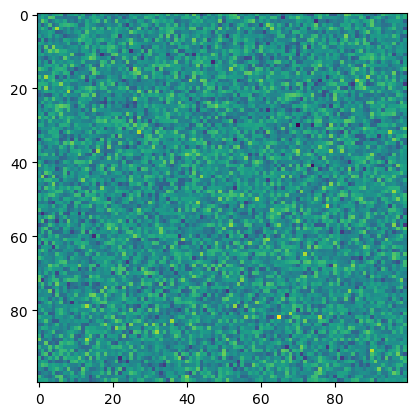

In [5]:
images = train.data
noise = torch.randn((100,100))
plt.imshow(noise)

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer = nn.Sequential(
            nn.Linear(100*100, 200),
            nn.ReLU(),
            nn.Linear(200, 28*28),
            nn.Sigmoid()
        )
    def forward(self, X):
        X = self.flatten(X)
        return self.layer(X)

'Using cpu'

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
f'using {device}'

'using cpu'

In [ ]:
gen = Generator().to(device)

In [18]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer = nn.Sequential(
            nn.Linear(28*28, 200),
            nn.ReLU(),
            nn.Linear(200, 1),
            nn.Sigmoid()
        )
    def forward(self, X):
        X = self.flatten(X)
        return self.layer(X)

In [19]:
dec = Discriminator().to(device)

In [ ]:
loss_gen = nn.BCELoss()
loss_dec = nn.BCELoss()